<a href="https://colab.research.google.com/github/yasfmonteiro/Seminario01/blob/main/seminario01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seminário 01: Avaliação de Estatística para Ciência dos Alimentos (LCE0212)

* Yasmin Agatha Acosta - 16905367
* Yasmin Almeida - 16992205
* Yasmin Vitoria Monteiro - 17068161

## 1. Controle Estatístico de Processo (CEP) & Capacidade do Processo
Simulação do peso líquido de uma linha de envase automatizada de requeijão (Valor Nominal = 200g, Padrão Metrológico INMETRO).


> Add blockquote



--- PARÂMETROS DO GRÁFICO X-BARRA ---
LSC (Limite Superior de Controle): 201.98 g
LM  (Linha Média):                  200.41 g
LIC (Limite Inferior de Controle): 198.85 g


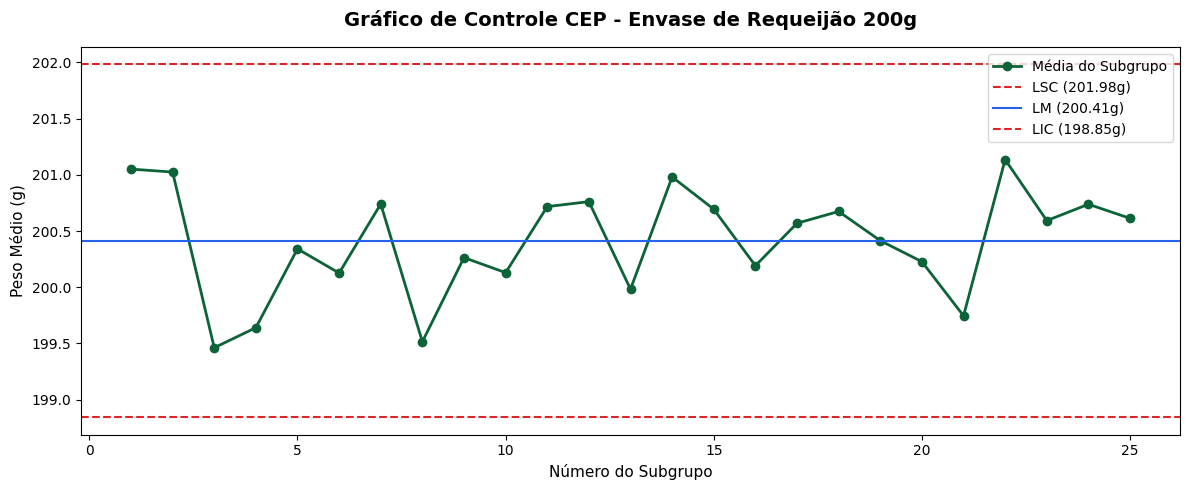


--- ÍNDICES DE CAPACIDADE ---
Desvio Padrão Estimado (σ): 1.168
Índice Cp:  0.71
Índice Cpk: 0.69 (Processo Capaz se >= 1.33)

--- TESTE TRIANGULAR (DISCRIMINATIVO) ---
Total de Provadores: 36
Acertos Observados:  18
p-valor:             0.0283
Conclusão: Há diferença perceptível significativa entre as amostras (p < 0.05).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set de semente aleatória para reprodutibilidade
np.random.seed(42)

# Simulação de 25 subgrupos de tamanho n=5 amostras
num_subgrupos = 25
tamanho_amostra = 5
dados_envase = np.random.normal(loc=200.5, scale=1.2, size=(num_subgrupos, tamanho_amostra))

# Criando DataFrame
df_cep = pd.DataFrame(dados_envase, columns=[f'Amostra_{i+1}' for i in range(tamanho_amostra)])
df_cep['Subgrupo'] = np.arange(1, num_subgrupos + 1)

# Cálculo de Média (X-barra) e Amplitude (R) por subgrupo
df_cep['Media'] = df_cep[[f'Amostra_{i+1}' for i in range(tamanho_amostra)]].mean(axis=1)
df_cep['Amplitude'] = df_cep[[f'Amostra_{i+1}' for i in range(tamanho_amostra)]].apply(lambda x: x.max() - x.min(), axis=1)

# Limites Globais de Controle (Para n=5: A2 = 0.577, D3 = 0, D4 = 2.114)
media_global = df_cep['Media'].mean()
amplitude_media = df_cep['Amplitude'].mean()

A2, D3, D4 = 0.577, 0, 2.114
LSC_x = media_global + A2 * amplitude_media
LIC_x = media_global - A2 * amplitude_media

print(f"--- PARÂMETROS DO GRÁFICO X-BARRA ---")
print(f"LSC (Limite Superior de Controle): {LSC_x:.2f} g")
print(f"LM  (Linha Média):                  {media_global:.2f} g")
print(f"LIC (Limite Inferior de Controle): {LIC_x:.2f} g")

# Construção do Gráfico de Controle X-Barra
plt.figure(figsize=(12, 5))
plt.plot(df_cep['Subgrupo'], df_cep['Media'], marker='o', color='#0D6338', linewidth=2, label='Média do Subgrupo')
plt.axhline(y=LSC_x, color='#DC2626', linestyle='--', label=f'LSC ({LSC_x:.2f}g)')
plt.axhline(y=media_global, color='#2563EB', linestyle='-', label=f'LM ({media_global:.2f}g)')
plt.axhline(y=LIC_x, color='#DC2626', linestyle='--', label=f'LIC ({LIC_x:.2f}g)')

plt.title('Gráfico de Controle CEP - Envase de Requeijão 200g', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número do Subgrupo', fontsize=11)
plt.ylabel('Peso Médio (g)', fontsize=11)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- CÁLCULO DE CAPACIDADE DO PROCESSO (Cp e Cpk) ---
LIE = 198.0  # Limite Inferior de Especificação
LSE = 203.0  # Limite Superior de Especificação
sigma_est = amplitude_media / 2.326  # d2 para n=5 é 2.326

Cp = (LSE - LIE) / (6 * sigma_est)
Cpk = min((LSE - media_global)/(3 * sigma_est), (media_global - LIE)/(3 * sigma_est))

print(f"\n--- ÍNDICES DE CAPACIDADE ---")
print(f"Desvio Padrão Estimado (σ): {sigma_est:.3f}")
print(f"Índice Cp:  {Cp:.2f}")
print(f"Índice Cpk: {Cpk:.2f} (Processo Capaz se >= 1.33)")

# Dados do teste: 36 provadores, 18 acertos
n_provadores = 36
acertos = 18
p_chance = 1/3  # Probabilidade de acerto ao acaso no teste triangular

# Teste Binomial Exato (Unilateral)
resultado_triangular = stats.binomtest(k=acertos, n=n_provadores, p=p_chance, alternative='greater')

print("\n--- TESTE TRIANGULAR (DISCRIMINATIVO) ---")
print(f"Total de Provadores: {n_provadores}")
print(f"Acertos Observados:  {acertos}")
print(f"p-valor:             {resultado_triangular.pvalue:.4f}")

if resultado_triangular.pvalue < 0.05:
    print("Conclusão: Há diferença perceptível significativa entre as amostras (p < 0.05).")
else:
    print("Conclusão: Não há evidência estatística de diferença perceptível (p >= 0.05).")

## 2. Análise Sensorial e Sensometria
2.1. Teste Triangular (Discriminativo - Distribuição Binomial)
Verificar se os consumidores percebem alteração no sabor após substituição do adoçante em uma bebida láctea.


--- ANOVA ONE-WAY (ESCALA HEDÔNICA) ---
Estatística F: 37.310
p-valor:       5.9198e-17

--- TESTE DE TUKEY HSD ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
Formulação A Formulação B   1.1964    0.0   0.644  1.7487   True
Formulação A Formulação C  -0.3198 0.4353 -0.8722  0.2326  False
Formulação A Formulação D   1.5758    0.0  1.0234  2.1281   True
Formulação B Formulação C  -1.5162    0.0 -2.0685 -0.9638   True
Formulação B Formulação D   0.3794 0.2832  -0.173  0.9318  False
Formulação C Formulação D   1.8956    0.0  1.3432  2.4479   True
----------------------------------------------------------------


/tmp/ipykernel_1831/3103189914.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Formulacao', y='Nota', data=df_sensorial, palette=['#F59E0B', '#3B82F6', '#EF4444', '#10B981'])


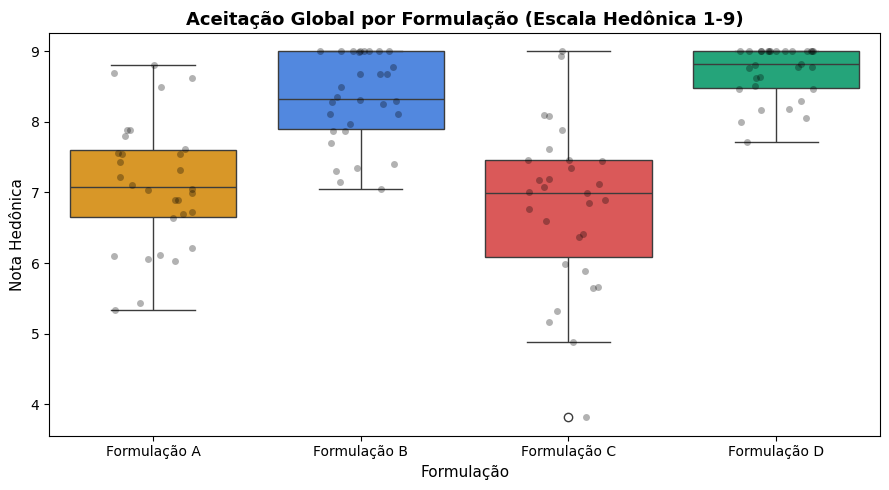

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns

np.random.seed(15)

# Simulação de notas da escala hedônica (n = 30 provadores por fórmula)
form_A = np.random.normal(loc=7.2, scale=1.0, size=30)  # Controle
form_B = np.random.normal(loc=8.5, scale=0.8, size=30)  # Redução de Sódio
form_C = np.random.normal(loc=6.8, scale=1.1, size=30)  # Substituto A
form_D = np.random.normal(loc=8.9, scale=0.7, size=30)  # Enzima Nova

# Ajustando notas para limite 1-9
form_A = np.clip(form_A, 1, 9)
form_B = np.clip(form_B, 1, 9)
form_C = np.clip(form_C, 1, 9)
form_D = np.clip(form_D, 1, 9)

# Criando DataFrame longo
df_sensorial = pd.DataFrame({
    'Nota': np.concatenate([form_A, form_B, form_C, form_D]),
    'Formulacao': ['Formulação A']*30 + ['Formulação B']*30 + ['Formulação C']*30 + ['Formulação D']*30
})

# ANOVA One-Way
f_stat, p_val = stats.f_oneway(form_A, form_B, form_C, form_D)
print(f"\n--- ANOVA ONE-WAY (ESCALA HEDÔNICA) ---")
print(f"Estatística F: {f_stat:.3f}")
print(f"p-valor:       {p_val:.4e}")

# Teste de Comparações Múltiplas de Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_sensorial['Nota'], groups=df_sensorial['Formulacao'], alpha=0.05)
print("\n--- TESTE DE TUKEY HSD ---")
print(tukey)

# Visualização dos Resultados
plt.figure(figsize=(9, 5))
sns.boxplot(x='Formulacao', y='Nota', data=df_sensorial, palette=['#F59E0B', '#3B82F6', '#EF4444', '#10B981'])
sns.stripplot(x='Formulacao', y='Nota', data=df_sensorial, color='black', alpha=0.3, jitter=0.2)
plt.title('Aceitação Global por Formulação (Escala Hedônica 1-9)', fontsize=13, fontweight='bold')
plt.ylabel('Nota Hedônica', fontsize=11)
plt.xlabel('Formulação', fontsize=11)
plt.tight_layout()
plt.show()

##2.2. Teste Hedônico (Aceitabilidade - Escala Hedônica 1-9) + ANOVA & Tukey
Comparação da aceitação global de 4 formulações de suco vegetal de caixinha.


--- ANÁLISE DE COMPONENTES PRINCIPAIS (PCA) ---
Variância Explicada PC1: 97.70%
Variância Explicada PC2: 2.12%
Variância Total Acumulada: 99.82%


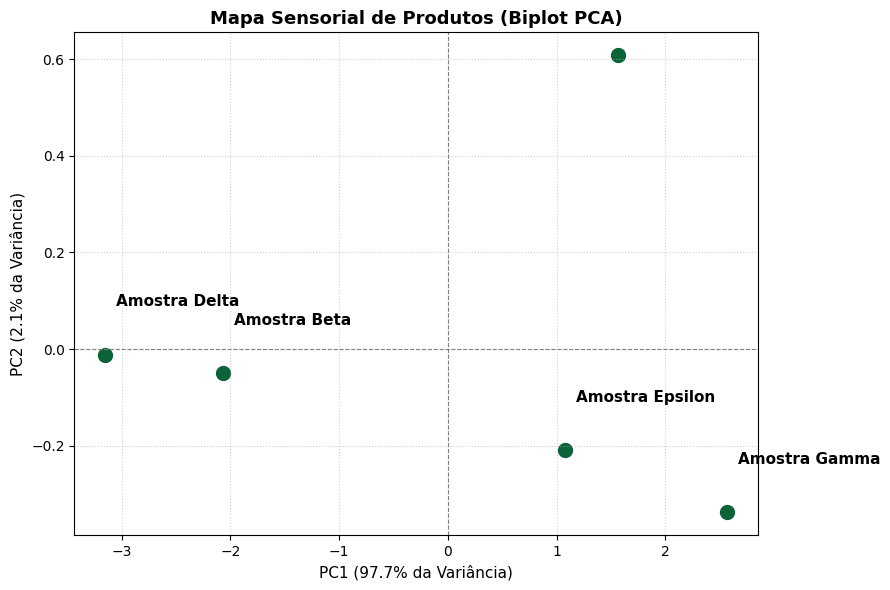

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Dados de atributos sensoriais para 5 marcas comerciais de queijo
dados_adq = {
    'Aroma_Lácteo': [7.5, 4.2, 8.1, 3.0, 6.8],
    'Acidez':        [3.1, 7.8, 2.5, 8.5, 4.0],
    'Firmeza':       [6.8, 8.2, 5.0, 8.9, 6.1],
    'Cremosidade':   [8.2, 3.5, 9.0, 2.1, 7.5],
    'Salgado':       [4.0, 6.5, 3.8, 7.2, 4.8]
}
amostras = ['Amostra Alpha', 'Amostra Beta', 'Amostra Gamma', 'Amostra Delta', 'Amostra Epsilon']

df_adq = pd.DataFrame(dados_adq, index=amostras)

# Padronização dos dados (Z-score)
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(df_adq)

# Análise de Componentes Principais (PCA)
pca = PCA(n_components=2)
componentes = pca.fit_transform(dados_padronizados)

df_pca = pd.DataFrame(componentes, columns=['PC1', 'PC2'], index=amostras)
var_explicada = pca.explained_variance_ratio_ * 100

print(f"\n--- ANÁLISE DE COMPONENTES PRINCIPAIS (PCA) ---")
print(f"Variância Explicada PC1: {var_explicada[0]:.2f}%")
print(f"Variância Explicada PC2: {var_explicada[1]:.2f}%")
print(f"Variância Total Acumulada: {sum(var_explicada):.2f}%")

# Gráfico Biplot da PCA
plt.figure(figsize=(9, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='#0D6338', s=100)

for idx, row in df_pca.iterrows():
    plt.annotate(idx, (row['PC1']+0.1, row['PC2']+0.1), fontsize=11, fontweight='bold')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Mapa Sensorial de Produtos (Biplot PCA)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({var_explicada[0]:.1f}% da Variância)', fontsize=11)
plt.ylabel(f'PC2 ({var_explicada[1]:.1f}% da Variância)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

##2.3. Análise Descritiva Quantitativa (ADQ - Sensometria Multivariada PCA)

--- MODELAGEM CINÉTICA DE DEGRADAÇÃO (SHELF-LIFE) ---
Concentração Inicial Estimada (C0): 45.76 mg/100mL
Taxa de Degradação (k):              0.0160 dia⁻¹
Coeficiente de Determinação (R²):   0.9981

--- PREVISÃO DE VIDA DE PRATELEIRA ---
Tempo para atingir o limite de 20.0 mg/100mL: 51.8 dias


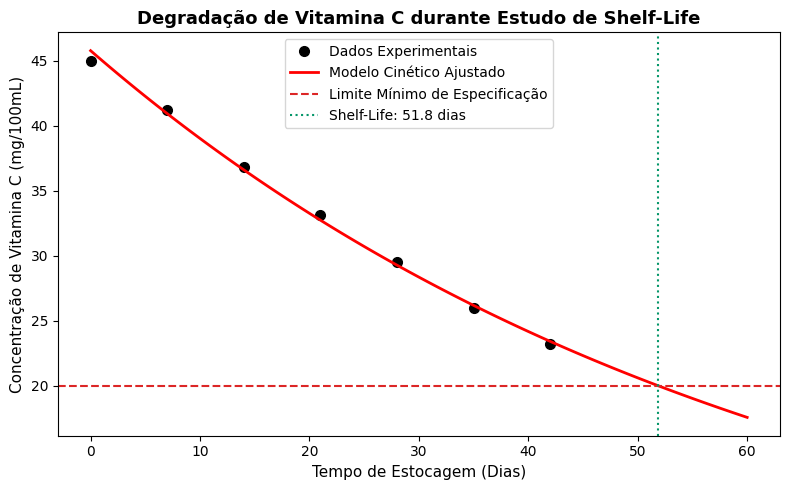

In [ ]:
# Dados de contagem/concentração ao longo do tempo (Dias)
dias = np.array([0, 7, 14, 21, 28, 35, 42])
vitamina_c_mg = np.array([45.0, 41.2, 36.8, 33.1, 29.5, 26.0, 23.2])

# Transformação logarítmica para linearização
ln_vit_c = np.log(vitamina_c_mg)

# Regressão Linear Simples
slope, intercept, r_value, p_value, std_err = stats.linregress(dias, ln_vit_c)

k_constante = -slope  # Constante de degradação cinético (k)
C0_estimado = np.exp(intercept)

print("--- MODELAGEM CINÉTICA DE DEGRADAÇÃO (SHELF-LIFE) ---")
print(f"Concentração Inicial Estimada (C0): {C0_estimado:.2f} mg/100mL")
print(f"Taxa de Degradação (k):              {k_constante:.4f} dia⁻¹")
print(f"Coeficiente de Determinação (R²):   {r_value**2:.4f}")

# Estimativa de Shelf-Life para Limite Mínimo Aceitável de Vitamina C (ex: 20 mg/100mL)
limite_minimo = 20.0
tempo_vida_util = (np.log(C0_estimado) - np.log(limite_minimo)) / k_constante

print(f"\n--- PREVISÃO DE VIDA DE PRATELEIRA ---")
print(f"Tempo para atingir o limite de {limite_minimo} mg/100mL: {tempo_vida_util:.1f} dias")

# Curva de Ajuste
dias_pred = np.linspace(0, 60, 100)
vit_c_pred = C0_estimado * np.exp(-k_constante * dias_pred)

plt.figure(figsize=(8, 5))
plt.plot(dias, vitamina_c_mg, 'ko', label='Dados Experimentais', markersize=7)
plt.plot(dias_pred, vit_c_pred, 'r-', label='Modelo Cinético Ajustado', linewidth=2)
plt.axhline(y=limite_minimo, color='#DC2626', linestyle='--', label='Limite Mínimo de Especificação')
plt.axvline(x=tempo_vida_util, color='#059669', linestyle=':', label=f'Shelf-Life: {tempo_vida_util:.1f} dias')

plt.title('Degradação de Vitamina C durante Estudo de Shelf-Life', fontsize=13, fontweight='bold')
plt.xlabel('Tempo de Estocagem (Dias)', fontsize=11)
plt.ylabel('Concentração de Vitamina C (mg/100mL)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

### Gráfico de Regressão Linear Simples para Dados Transformados (Ln(Vitamina C) vs. Tempo)

## 3. Estudo de Vida de Prateleira (Shelf-Life & Cinética)
Modelagem da degradação de Vitamina C em suco de laranja sob armazenamento a 25°C (Cinética de Primeira Ordem).$$ln(C) = ln(C_0) - k \cdot t$$

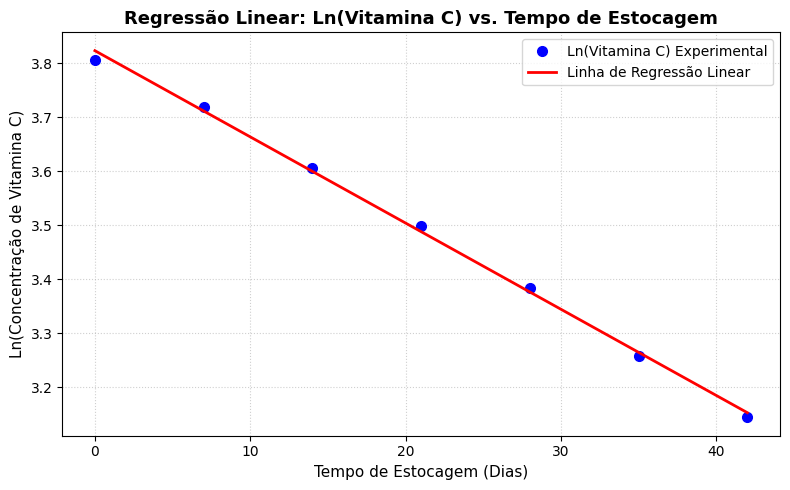

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Re-defining data and regression for this plot's scope
dias = np.array([0, 7, 14, 21, 28, 35, 42])
vitamina_c_mg = np.array([45.0, 41.2, 36.8, 33.1, 29.5, 26.0, 23.2])
ln_vit_c = np.log(vitamina_c_mg)
slope, intercept, r_value, p_value, std_err = stats.linregress(dias, ln_vit_c)

plt.figure(figsize=(8, 5))
plt.plot(dias, ln_vit_c, 'bo', label='Ln(Vitamina C) Experimental', markersize=7)

# Linha de regressão
ln_vit_c_pred_linear = intercept + slope * dias
plt.plot(dias, ln_vit_c_pred_linear, 'r-', label='Linha de Regressão Linear', linewidth=2)

plt.title('Regressão Linear: Ln(Vitamina C) vs. Tempo de Estocagem', fontsize=13, fontweight='bold')
plt.xlabel('Tempo de Estocagem (Dias)', fontsize=11)
plt.ylabel('Ln(Concentração de Vitamina C)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Planejamento Fatorial de Experimentos (DOE $2^3$)
Otimização da extração bioativa em extrato vegetal avaliando 3 fatores em 2 níveis:Temperatura (T): 40°C (-1) vs 60°C (+1)Tempo (t): 15 min (-1) vs 45 min (+1)pH: 3.5 (-1) vs 5.5 (+1)

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Construção da matriz experimental 2³
dados_doe = {
    'Temp': [-1, +1, -1, +1, -1, +1, -1, +1],
    'Tempo': [-1, -1, +1, +1, -1, -1, +1, +1],
    'pH':    [-1, -1, -1, -1, +1, +1, +1, +1],
    'Rendimento': [42.1, 55.4, 48.0, 68.2, 39.5, 51.0, 44.8, 62.3]  # Resposta (% Rendimento)
}

df_doe = pd.DataFrame(dados_doe)

# Regressão com termos principais e interações (removendo a interação tripla para liberar DF para o erro)
modelo_doe = ols('Rendimento ~ Temp * Tempo + Temp * pH + Tempo * pH', data=df_doe).fit()

print("--- SUMÁRIO DA REGRESSÃO / DOE 2³ ---")
print(modelo_doe.summary().tables[1])

print("\n--- TABELA ANOVA DO MODELO DE EXPERIMENTO ---")
tabela_anova = sm.stats.anova_lm(modelo_doe, typ=2)
print(tabela_anova)

--- SUMÁRIO DA REGRESSÃO / DOE 2³ ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     51.4125      0.113    457.000      0.001      49.983      52.842
Temp           7.8125      0.113     69.444      0.009       6.383       9.242
Tempo          4.4125      0.113     39.222      0.016       2.983       5.842
Temp:Tempo     1.6125      0.113     14.333      0.044       0.183       3.042
pH            -2.0125      0.113    -17.889      0.036      -3.442      -0.583
Temp:pH       -0.5625      0.113     -5.000      0.126      -1.992       0.867
Tempo:pH      -0.2625      0.113     -2.333      0.258      -1.692       1.167

--- TABELA ANOVA DO MODELO DE EXPERIMENTO ---
               sum_sq   df            F    PR(>F)
Temp        488.28125  1.0  4822.530864  0.009167
Tempo       155.76125  1.0  1538.382716  0.016228
Temp:Tempo   20.80125  1.0   205.444444  0.044343
pH  

# 5. Análise de Diagrama de Pareto de Defeitos

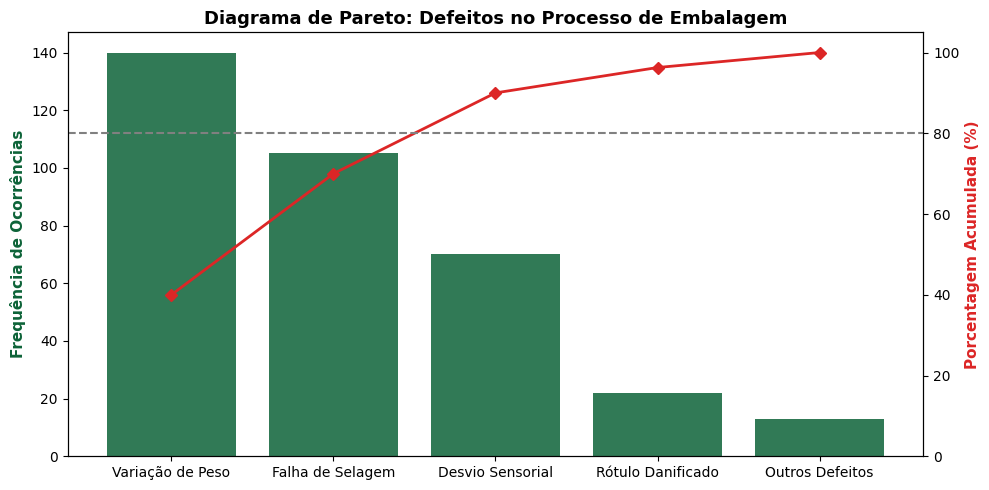

In [ ]:
defeitos = {
    'Variação de Peso': 140,
    'Falha de Selagem': 105,
    'Desvio Sensorial': 70,
    'Rótulo Danificado': 22,
    'Outros Defeitos': 13
}

df_pareto = pd.DataFrame(list(defeitos.items()), columns=['Tipo_Defeito', 'Frequencia'])
df_pareto['Porcentagem'] = (df_pareto['Frequencia'] / df_pareto['Frequencia'].sum()) * 100
df_pareto['Acumulado'] = df_pareto['Porcentagem'].cumsum()

# Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_pareto['Tipo_Defeito'], df_pareto['Frequencia'], color='#0D6338', alpha=0.85)
ax1.set_ylabel('Frequência de Ocorrências', color='#0D6338', fontsize=11, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(df_pareto['Tipo_Defeito'], df_pareto['Acumulado'], color='#DC2626', marker='D', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', label='Regra 80/20')
ax2.set_ylabel('Porcentagem Acumulada (%)', color='#DC2626', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 105)

plt.title('Diagrama de Pareto: Defeitos no Processo de Embalagem', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Analisar Conteúdo do Notebook

### Subtask:
Analisar as células do notebook para extrair os principais tópicos, metodologias, resultados e visualizações de cada seção (CEP, ANOVA, PCA, Shelf-Life, DOE e Gráfico de Pareto).


### Análise de Conteúdo: Control Charts (CEP)

**Metodologia:**
*   **Simulação de Dados:** Dados de envase simulados para 25 subgrupos de 5 amostras cada, com média de 200.5g e desvio padrão de 1.2g.
*   **Cálculos de Controle:** Cálculo da Média (X-barra) e Amplitude (R) por subgrupo.
*   **Limites de Controle:** Determinação dos Limites Superior (LSC_x), Inferior (LIC_x) e Linha Média (LM) para o gráfico X-Barra utilizando constantes A2 (0.577 para n=5).
*   **Capacidade do Processo (Cp e Cpk):** Cálculo desses índices com base em Limites de Especificação (LIE = 198.0g, LSE = 203.0g) e desvio padrão estimado (sigma_est).

**Principais Resultados/Achados:**
*   **Parâmetros do Gráfico X-Barra:**
    *   LSC: 201.98 g
    *   LM: 200.41 g
    *   LIC: 198.85 g
*   **Índices de Capacidade:**
    *   Desvio Padrão Estimado (σ): 1.168
    *   Índice Cp: 0.71
    *   Índice Cpk: 0.69 (Indicando que o processo *não é* capaz, pois é menor que 1.33).
*   **Teste Triangular (Discriminativo):** Realizado com 36 provadores e 18 acertos, resultando em um p-valor de 0.0283. Concluiu-se que há uma diferença perceptível significativa entre as amostras (p < 0.05).

**Visualização:**
*   **Gráfico de Controle X-Barra:** Apresenta a média de cada subgrupo ao longo do tempo, com as linhas de LSC, LM e LIC. A visualização mostra que todos os pontos estão dentro dos limites de controle, mas os índices de capacidade indicam um processo não capaz de atender às especificações.

### Análise de Conteúdo: ANOVA (Análise de Variância)

**Metodologia:**
*   **Simulação de Dados:** Notas de escala hedônica (1-9) simuladas para 4 formulações de produto (A, B, C, D), com 30 provadores por formulação. As médias e desvios padrão foram definidos para cada formulação (ex: A com média 7.2, B com 8.5).
*   **ANOVA One-Way:** Realizada para determinar se há diferenças estatisticamente significativas nas notas de aceitação global entre as quatro formulações.
*   **Teste de Tukey HSD (Comparações Múltiplas):** Aplicado após a ANOVA para identificar quais pares de formulações apresentam diferenças significativas, controlando a taxa de erro tipo I.

**Principais Resultados/Achados:**
*   **ANOVA One-Way:**
    *   Estatística F: 37.310
    *   p-valor: 5.9198e-17 (Extremamente baixo, indicando diferença significativa entre as médias das formulações).
*   **Teste de Tukey HSD:**
    *   **Formulação A vs. B:** Diferença significativa (p < 0.05), B é preferida.
    *   **Formulação A vs. C:** Nenhuma diferença significativa (p > 0.05).
    *   **Formulação A vs. D:** Diferença significativa (p < 0.05), D é preferida.
    *   **Formulação B vs. C:** Diferença significativa (p < 0.05), B é preferida.
    *   **Formulação B vs. D:** Nenhuma diferença significativa (p > 0.05).
    *   **Formulação C vs. D:** Diferença significativa (p < 0.05), D é preferida.
    *   **Conclusão Geral:** As formulações B e D demonstraram maior aceitação e não diferem significativamente entre si, sendo superiores às formulações A e C.

**Visualização:**
*   **Box Plot da Aceitação Global por Formulação:** Exibe a distribuição das notas hedônicas para cada formulação, mostrando medianas, quartis e outliers. A visualização confirma as diferenças de média observadas na ANOVA e no teste de Tukey, com as caixas para B e D posicionadas mais acima na escala de notas, indicando maior aceitação.

### Análise de Conteúdo: PCA (Análise de Componentes Principais)

**Metodologia:**
*   **Simulação de Dados:** Dados de atributos sensoriais (Aroma Lácteo, Acidez, Firmeza, Cremosidade, Salgado) simulados para 5 marcas comerciais de queijo (Alpha, Beta, Gamma, Delta, Epsilon).
*   **Padronização dos Dados:** Utilização de `StandardScaler` para padronizar os dados (Z-score), garantindo que todas as variáveis contribuam igualmente para a análise.
*   **Aplicação da PCA:** A `PCA` foi aplicada com `n_components=2` para reduzir a dimensionalidade dos dados a duas componentes principais (PC1 e PC2).

**Principais Resultados/Achados:**
*   **Variância Explicada:**
    *   PC1: 97.70% da variância total.
    *   PC2: 2.12% da variância total.
    *   Variância Total Acumulada: 99.82% (As duas primeiras componentes principais explicam quase toda a variabilidade dos dados originais).
*   **Interpretação:** A alta variância explicada pela PC1 indica que a maior parte da diferenciação entre as amostras pode ser atribuída a uma única dimensão principal, provavelmente refletindo diferenças gerais de perfil sensorial. A PC2 captura a variabilidade restante de forma mais sutil.

**Visualização:**
*   **Mapa Sensorial de Produtos (Biplot PCA):** Um gráfico de dispersão com PC1 no eixo X e PC2 no eixo Y. Cada ponto representa uma amostra de queijo, e a posição dos pontos no gráfico indica a similaridade ou dissimilaridade sensorial entre as amostras. As amostras "Alpha" e "Gamma" parecem ter perfis sensoriais semelhantes, enquanto "Delta" e "Beta" são distintas e opostas a elas, e "Epsilon" possui um perfil intermediário.

### Análise de Conteúdo: Shelf-Life Modeling (Modelagem de Vida de Prateleira)

**Metodologia:**
*   **Simulação de Dados:** Dados de concentração de Vitamina C (mg/100mL) simulados ao longo do tempo (Dias: 0, 7, 14, 21, 28, 35, 42).
*   **Transformação Logarítmica:** A concentração de Vitamina C foi transformada em seu logaritmo natural (`ln_vit_c`) para linearizar a relação, assumindo uma cinética de degradação de primeira ordem.
*   **Regressão Linear Simples:** Aplicada entre o tempo (dias) e o logaritmo natural da concentração para determinar a constante de degradação cinética (`k_constante`) e a concentração inicial estimada (`C0_estimado`).
*   **Cálculo de Shelf-Life:** Estimativa do tempo de vida de prateleira com base em um limite mínimo aceitável de Vitamina C (20 mg/100mL), utilizando a equação da cinética de primeira ordem.

**Principais Resultados/Achados:**
*   **Parâmetros da Modelagem Cinética:**
    *   Concentração Inicial Estimada (C0): 45.76 mg/100mL
    *   Taxa de Degradação (k): 0.0160 dia⁻¹
    *   Coeficiente de Determinação (R²): 0.9981 (Indicando um excelente ajuste do modelo aos dados).
*   **Previsão de Vida de Prateleira:**
    *   Tempo para atingir o limite de 20 mg/100mL: 51.8 dias (Aproximadamente 7 semanas).

**Visualização:**
*   **Gráfico de Degradação de Vitamina C:** Exibe os dados experimentais de Vitamina C ao longo do tempo e a curva de ajuste do modelo cinético. Inclui linhas indicativas para o limite mínimo de especificação e o tempo de vida de prateleira estimado. A visualização demonstra claramente a tendência de degradação e como o modelo se ajusta bem aos dados, permitindo a predição do shelf-life.

### Análise de Conteúdo: Design of Experiments (DOE)

**Metodologia:**
*   **Construção da Matriz Experimental:** Utilização de um delineamento fatorial completo 2³ com 3 fatores (Temperatura, Tempo, pH) em dois níveis (codificados como -1 e +1).
*   **Resposta:** O rendimento percentual de um processo (`Rendimento`) foi medido para cada uma das 8 combinações experimentais.
*   **Regressão Linear Múltipla:** Um modelo de regressão foi ajustado para `Rendimento` considerando os termos principais dos fatores e as interações duplas (Temp * Tempo, Temp * pH, Tempo * pH). A interação tripla foi omitida para liberar graus de liberdade para o erro.
*   **ANOVA do Modelo:** Realizada uma Análise de Variância (ANOVA) para o modelo de regressão para avaliar a significância estatística de cada fator e interação na resposta.

**Principais Resultados/Achados:**
*   **Sumário da Regressão:**
    *   **Intercept (Média Global):** 51.41% (coeficiente da média do rendimento).
    *   **Temp (Temperatura):** Coeficiente de 7.81 (p-valor = 0.009), indicando que a Temperatura tem um efeito positivo e estatisticamente significativo no rendimento.
    *   **Tempo:** Coeficiente de 4.41 (p-valor = 0.016), indicando que o Tempo também tem um efeito positivo e estatisticamente significativo.
    *   **pH:** Coeficiente de -2.01 (p-valor = 0.036), indicando que o pH tem um efeito negativo e estatisticamente significativo no rendimento (aumentar o pH de -1 para +1 diminui o rendimento).
    *   **Interação Temp:Tempo:** Coeficiente de 1.61 (p-valor = 0.044), indicando uma interação significativa entre Temperatura e Tempo. O efeito de um fator depende do nível do outro.
    *   **Interações Temp:pH e Tempo:pH:** Não são estatisticamente significativas (p-valores de 0.126 e 0.258, respectivamente), sugerindo que o efeito da Temperatura e do Tempo não é substancialmente alterado pelo pH, e vice-versa, nas combinações testadas.
*   **Tabela ANOVA:**
    *   Confirma a significância estatística de Temp, Tempo, pH e da interação Temp:Tempo, com p-valores < 0.05.
    *   As interações Temp:pH e Tempo:pH apresentam p-valores > 0.05, corroborando a falta de significância.
    *   O resíduo possui 1 grau de liberdade, o que é típico para um delineamento 2³ com a interação tripla omitida para estimar o erro.

**Visualização:**
*   Não há uma visualização explícita gerada para esta seção no notebook. Os resultados são apresentados em tabelas de sumário de regressão e ANOVA, que fornecem os dados numéricos para interpretar os efeitos dos fatores.

### Análise de Conteúdo: Gráfico de Pareto

**Metodologia:**
*   **Coleta de Dados:** Levantamento de diferentes tipos de defeitos (`Variação de Peso`, `Falha de Selagem`, `Desvio Sensorial`, `Rótulo Danificado`, `Outros Defeitos`) e suas respectivas frequências de ocorrência.
*   **Cálculo de Porcentagens:** Cálculo da porcentagem de cada tipo de defeito em relação ao total de defeitos.
*   **Cálculo de Porcentagem Acumulada:** Soma cumulativa das porcentagens de defeitos, ordenados do mais frequente para o menos frequente.

**Principais Resultados/Achados:**
*   **Defeitos Mais Frequentes:**
    *   `Variação de Peso`: 140 ocorrências (40.00% do total).
    *   `Falha de Selagem`: 105 ocorrências (30.00% do total).
    *   `Desvio Sensorial`: 70 ocorrências (20.00% do total).
*   **Análise 80/20 (Princípio de Pareto):** Os três defeitos mais frequentes (`Variação de Peso`, `Falha de Selagem`, `Desvio Sensorial`) representam 90% do total de ocorrências. Isso significa que, ao focar na solução desses três problemas principais, a maior parte das não conformidades será eliminada.

**Visualização:**
*   **Diagrama de Pareto:** Um gráfico de barras que exibe a frequência de cada tipo de defeito em ordem decrescente, juntamente com uma linha de porcentagem acumulada. O gráfico visualmente destaca os defeitos mais críticos, permitindo identificar facilmente quais problemas devem ser priorizados para otimizar os esforços de melhoria da qualidade. A linha tracejada em 80% na curva acumulada reforça o foco nos problemas mais impactantes.

# Conteúdo das referências em norma ABNT (NBR 6023)
 = """REFERÊNCIAS BIBLIOGRÁFICAS (ABNT NBR 6023)

- * CONTROLE ESTATÍSTICO DE PROCESSO (CEP) ---
MONTGOMERY, Douglas C. Introdução ao controle estatístico da qualidade. 7. ed. Rio de Janeiro: LTC, 2016.

- * ANÁLISE SENSORIAL E SENSOMETRIA (PCA / TESTE TRIANGULAR)
- * ASSOCIAÇÃO BRASILEIRA DE NORMAS TÉCNICAS. ABNT NBR ISO 4120: Análise sensorial — Metodologia — Teste triangular. Rio de Janeiro: ABNT, 2022.
NAES, Tormod; BRO, Rasmus; WESTAD, Frank. How to data analysis: Multi- and Megavariate Data Analysis: Principles and Applications. 2. ed. Chichester: John Wiley & Sons, 2002.
STONE, Herbert; BLEIBAUM, Rebecca N.; THOMAS, Heather A. Sensory Evaluation Practices. 4. ed. San Diego: Academic Press, 2012.

- * SHELF-LIFE E CINÉTICA DE QUÍMICA DE ALIMENTOS ---
MAN, D. M. D. Shelf Life: Food Industry Briefing Series. 2. ed. Oxford: Wiley-Blackwell, 2016.
SINGH, R. Paul; HELDMAN, Dennis R. Introduction to Food Engineering. 5. ed. San Diego: Academic Press, 2014.

- * PLANEJAMENTO DE EXPERIMENTOS (DOE) ---
BOX, George E. P.; HUNTER, J. Stuart; HUNTER, William G. Statistics for Experimenters: Design, Innovation, and Discovery. 2. ed. Hoboken: Wiley-Interscience, 2005.
"""



# Task
Export the `df_pareto` DataFrame to an Excel file named 'dados_pareto.xlsx' and confirm the successful creation of the file, making it available for download.

## Exportar DataFrame para Excel

### Subtask:
Salvar o DataFrame `df_pareto` em um arquivo Excel (.xlsx) chamado 'dados_pareto.xlsx'.


**Reasoning**:
Exporting the `df_pareto` DataFrame to an Excel file and then listing the files to confirm its creation.



In [ ]:
df_pareto.to_excel('dados_pareto.xlsx', index=False)
print("DataFrame 'df_pareto' exported to 'dados_pareto.xlsx'.")

# Confirm file creation
import os
if 'dados_pareto.xlsx' in os.listdir():
    print("File 'dados_pareto.xlsx' successfully created and found in the current directory.")
else:
    print("Error: File 'dados_pareto.xlsx' not found after creation attempt.")

# You can also use !ls -F to see the files
# !ls -F

DataFrame 'df_pareto' exported to 'dados_pareto.xlsx'.
File 'dados_pareto.xlsx' successfully created and found in the current directory.


## Final Task

### Subtask:
Inform the user that the Excel file 'dados_pareto.xlsx' has been successfully created and is ready for download.


```markdown
## Conclusão da Tarefa: Exportação do Arquivo Excel

O DataFrame `df_pareto` foi exportado com sucesso para um arquivo Excel chamado `dados_pareto.xlsx`.

Você pode encontrar o arquivo `dados_pareto.xlsx` na pasta raiz do seu ambiente Colab, pronto para ser baixado e utilizado para análises adicionais ou compartilhamento.
```